In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

<Figure size 640x480 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

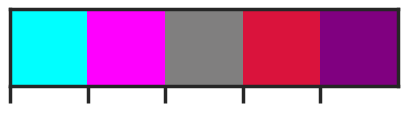

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

---

---

---

# Define the main functions first

In [4]:
def fun_1(objs):
    #load data and extract lick times
    rew_time_ls = []
    rew2_time_ls = []
    unrew_time_ls = []
    miss_ls= []
    for idx, x in enumerate(objs):
        if overall_order[idx] == '0':
            try:
                rew_time_ls.append(x.split("r")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])
        elif overall_order[idx] == '1':
            try:
                rew2_time_ls.append(x.split("z")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])            
        elif overall_order[idx] == '2':
            try:
                unrew_time_ls.append(x.split("o")[1].split(" ")[0].split("u")[0])
            except:
                print("Error{0}".format(idx))
    return rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls

In [6]:
def fun_2(objs, rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls, inter_dur):
    #converting the string to an array
    rew_time_ar = np.array(rew_time_ls, dtype=np.float32)
    rew2_time_ar = np.array(rew2_time_ls, dtype=np.float32)
    unrew_time_ar = np.array(unrew_time_ls, dtype=np.float32)
    miss_time_ar = np.array(miss_ls, dtype=np.float32)

    #subtracting the stimulus duration
    rew_times = rew_time_ar - inter_dur
    rew2_times = rew2_time_ar - inter_dur
    unrew_times = unrew_time_ar - inter_dur
    miss_times = miss_time_ar - inter_dur

    #removing the 'u', 'r', 'z', 'o' and 'm' identifiers
    cleaned_objs = [ x.replace('u', ' ') for x in objs if 'u' in x ]

    rew_cleaned = [ x.replace('r',' ') for x in cleaned_objs if 'r' in x ]
    rew2_cleaned = [ x.replace('z',' ') for x in cleaned_objs if 'z' in x ]
    unrew_cleaned = [ x.replace('o',' ') for x in cleaned_objs if 'o' in x ]
    miss_cleaned = [ x.replace('m',' ') for x in cleaned_objs if 'm' in x]
    
    rew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew_cleaned ]
    rew2_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew2_cleaned ]
    unrew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in unrew_cleaned ]
    miss_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in miss_cleaned ]

    for idx, val in enumerate(rew_time_ar):
        rew_lick[idx] =  rew_lick[idx][rew_lick[idx] != val]
    for idx, val in enumerate(rew2_time_ar):
        rew2_lick[idx] =  rew2_lick[idx][rew2_lick[idx] != val]
    for idx, val in enumerate(unrew_time_ar):
        unrew_lick[idx] =  unrew_lick[idx][unrew_lick[idx] != val]
    for idx, val in enumerate(miss_time_ar):
        miss_lick[idx] = miss_lick[idx][miss_lick[idx] != val]
        
    # Create data frame for the rewarded - water - trials
    rew_df = pd.DataFrame(rew_lick).sub(rew_times, axis = 0)
    num_rew_tr = rew_df.shape[0]
    # Create data frame for the rewarded - no water - trials
    rew2_df = pd.DataFrame(rew2_lick).sub(rew2_times, axis = 0)
    num_rew2_tr = rew2_df.shape[0]
    # Create data frame for the unrewarded trials
    unrew_df = pd.DataFrame(unrew_lick).sub(unrew_times, axis = 0)
    num_unrew_tr = unrew_df.shape[0]
    # Create a data frame for the rewarded trials that had no licks during stim time
    miss_df = pd.DataFrame(miss_lick).sub(miss_times, axis = 0)
    num_miss_tr = miss_df.shape[0]

    df_licks = pd.concat([rew_df, miss_df, rew2_df, unrew_df], ignore_index=True) # ~~~~~~~~~~the order here is important
    df_licks.drop(df_licks.index[0], inplace=True)
    df_licks2 = pd.DataFrame(df_licks.stack())
    
    return df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr

In [7]:
def fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr):
    test = df_licks.to_numpy()

    list_of_licks_per_trial = []
    counter = 0
    for i in range(num_rew_tr+num_rew2_tr+num_unrew_tr+num_miss_tr-1):
        for value in test[i]:
            if value > -100000000 and value < 10000000:
                counter += 1
            else:
                break
        list_of_licks_per_trial.append(counter)
        counter = 0

    list_reward_and_none = []
    for i, value in enumerate(list_of_licks_per_trial):
        for j in range(value):
            if i < num_rew_tr:       # Check if it's less than or less than or equal
                list_reward_and_none.append("rew")
            elif i > num_rew_tr and i < (num_rew_tr+num_rew2_tr):
                list_reward_and_none.append("rew2")
            elif i > (num_rew_tr+num_rew2_tr) and i < (num_rew_tr+num_rew2_tr+num_miss_tr):
                list_reward_and_none.append("miss")
            else:
                list_reward_and_none.append("unrew")
    
    df_licks2 = df_licks2.reset_index()
    df_licks2.columns = ["trial", "lick_idx", "lick_time"]

    df_licks2["stim_id"] = list_reward_and_none
    
    return df_licks2

---

---

---

# Main Function
Uses the defined path to load the .pkl files, extract and normalize the lick times, and organize it into a dataframe

In [16]:
#load data of all mice
# path = r"U:\Data\zimmer94\Behavior\oper_rec_licks\1sec"
# paradigm = 'RecInter'
# path = r"U:\Data\zimmer94\Behavior\oper_rec_licks\2sec"
# paradigm = 'RecInter2'

path = r"U:\Data\zimmer94\Behavior\licks"
paradigm = 'oper_disc' # pav, inter, oper_disc

matches = []
for root, dirnames, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(('.pkl')) and paradigm in filename and "bad" not in filename and "bad" not in root:
            matches.append(os.path.join(root, filename))
print ("# of file matches:", len(matches))

matches[0]

# of file matches: 793


'U:\\Data\\zimmer94\\Behavior\\licks\\07.07.21\\CC067431_HP1_oper_disc_2021-07-07_13-22-13.pkl'

---

---

---

# Define universal variables first

In [17]:
# u = start of trial
# m = no licks
# r = timestamp of reward
# z = rew2 stimulus
# o = unrew stimulus
# r, z, and o happen 1 sec after the stimulus ends

if paradigm == 'RecInter':
    interval = 1.0 # interval between the stimulus and reward
    stim_dur = 0.2
elif paradigm == 'RecInter2':
    interval = 2.0 # interval between the stimulus and reward
    stim_dur = 0.2
elif paradigm == 'pav':
    interval = 0.0
    stim_dur = 0.2
elif paradigm == 'inter':
    interval = 0.0
    stim_dur = 0.2
elif paradigm == 'oper_disc':
    interval = 1.0
    stim_dur = 0.2

inter_dur = interval+stim_dur

stim_lb = 0.0 #lower bound of stimulus time
stim_ub = 0.2 #upper bound of stimulus time
rew_lb = stim_lb+interval
rew_ub = stim_lb+interval+0.1

In [18]:
#Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
               0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
               0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
               0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
               1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
               0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

# #Psuedo random distribution of water to the rewarded stimuli
# # 0 -- water given -- 80 times
# # 1 -- no water given -- 20 times
# rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
#                0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
#                0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
#                0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

In [19]:
# overall_order = []
# i=0
# for idx,val in enumerate(stim_order):
#     if val == 0:
#         i = i+1
#         if rew_order[i-1] == 0:
#             overall_order.append('0') # rewH20
#         elif rew_order[i-1] == 1:
#             overall_order.append('1') # rewnoH20
#     elif val == 1:
#         overall_order.append('2')     # unrew
# print(len(overall_order))



overall_order = stim_order #use if no withheld trials

---

---

---

## Lick Count Raster Plots

In [20]:


save_plots = 0



In [21]:
## bins = np.arange(-2, 6.1, 0.1).round(3)
ls = []
for fn in matches[:]:
    f=open(fn, 'rb')
    objs = []
    while 1:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break
    f.close()

    cc = fn.split('\\')[-1].split('_')[0]
    hp = fn.split('\\')[-1].split('_')[1]
    combo = cc+hp


    rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
    df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                    rew_time_ls, 
                                                                                    rew2_time_ls, 
                                                                                    unrew_time_ls, 
                                                                                    miss_ls,
                                                                                    inter_dur)
    df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)



    # Plot licks across trials in the form of a dot plot
    fig_size = plt.rcParams["figure.figsize"]
    fig_size[0] = 8.0 # x dimension
    fig_size[1] = 3.0 # y dimension

    plt.plot( df_licks2.lick_time.values, df_licks2.trial, 'k.', markersize=3,label='_nolegend_')
    sns.despine()

    plt.title(combo)
    plt.xlim(-2, 7)
    greybar=plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="stim")
    bluebar=plt.axvspan(rew_lb, rew_ub, color='blue',alpha=0.25, label="water")

    rew2_lb = num_rew_tr + num_miss_tr
    rew2_ub = num_rew_tr + num_miss_tr + num_rew2_tr
    orangebar=plt.axhspan(rew2_lb, rew2_ub, color='orange', alpha=0.15, label="rew2")
    yellowbar=plt.axhspan(rew2_ub, 150, color='yellow',alpha=0.15, label="unrew")

    if save_plots == 1:
        save_folder = r"U:\Data\zimmer94\Behavior\oper_rec_licks\2sec"
        overall_path = save_file + '\\' + "raster_" + combo + r".pdf"
        plt.savefig(overall_path)

    plt.show()


ValueError: Unable to coerce to Series, length must be 77: given 0

---

---

---

# Big plots with raster & histogram for each of the situations
if issues arise with the subplot layout: "to restore the defaults, call plt.rcdefaults() " then rerun the first three cells in this notebook

In [78]:
save_big_plot = 0

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


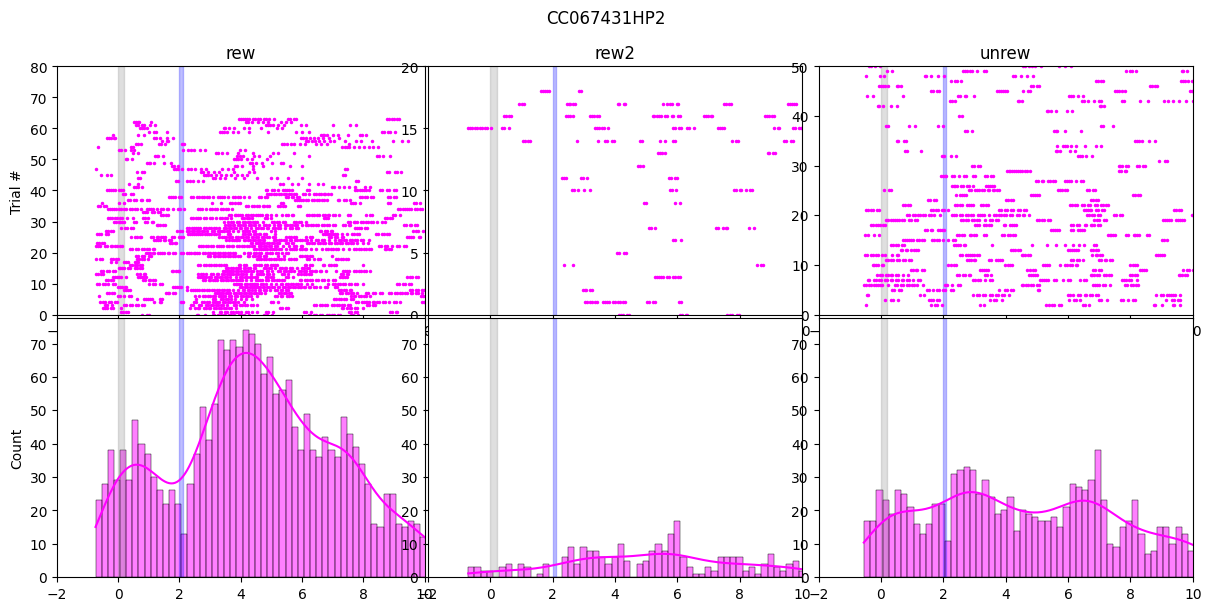

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


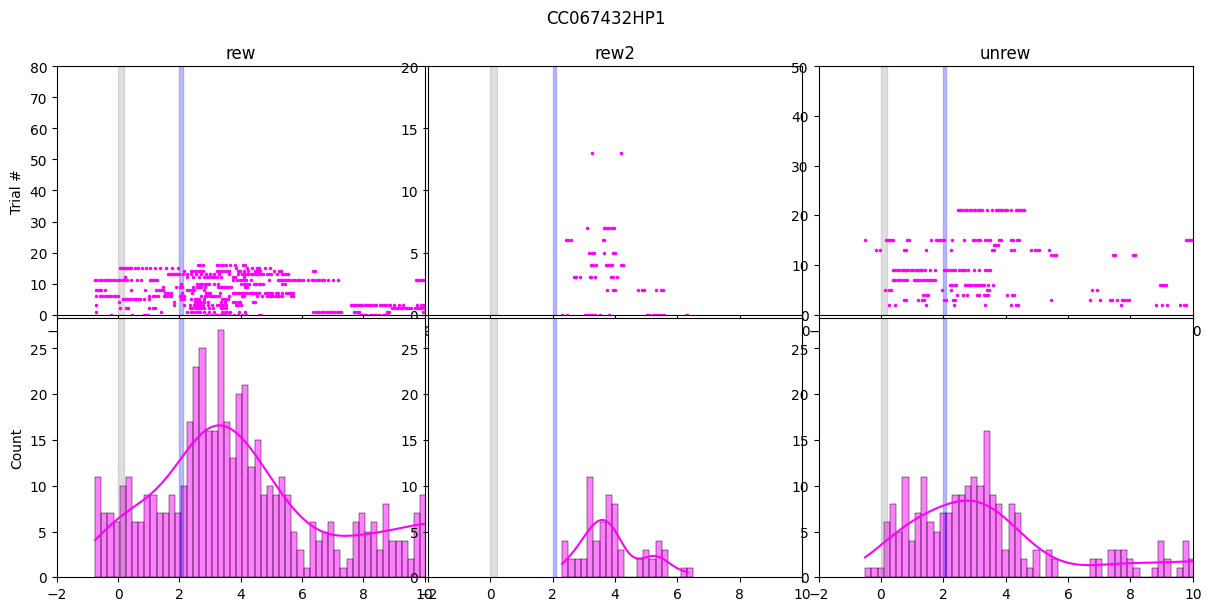

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


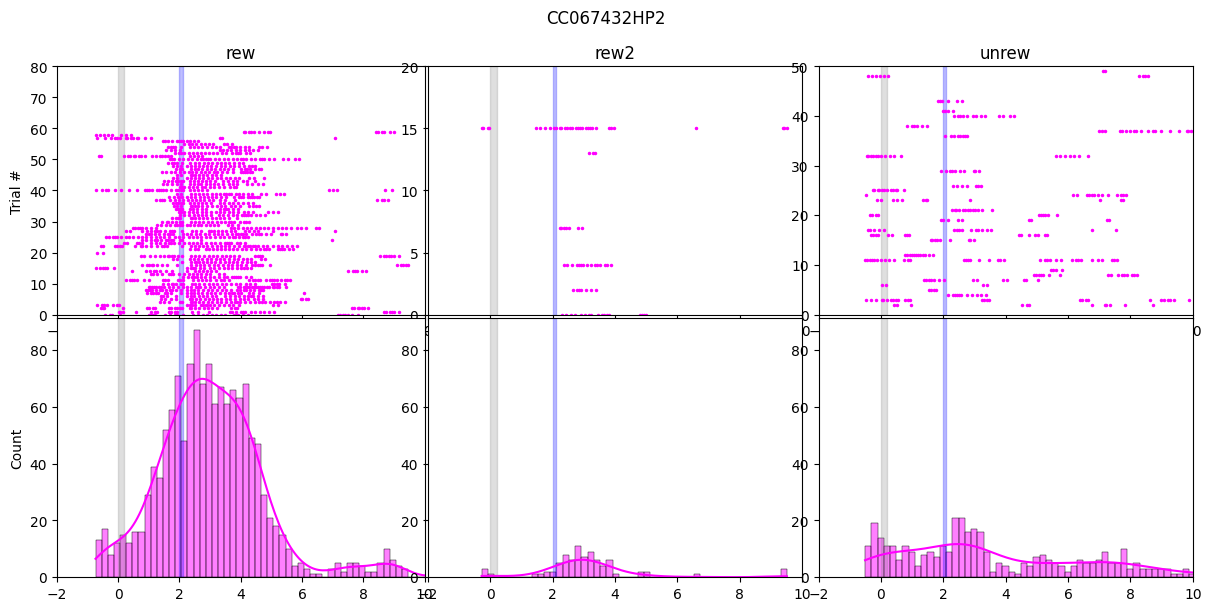

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


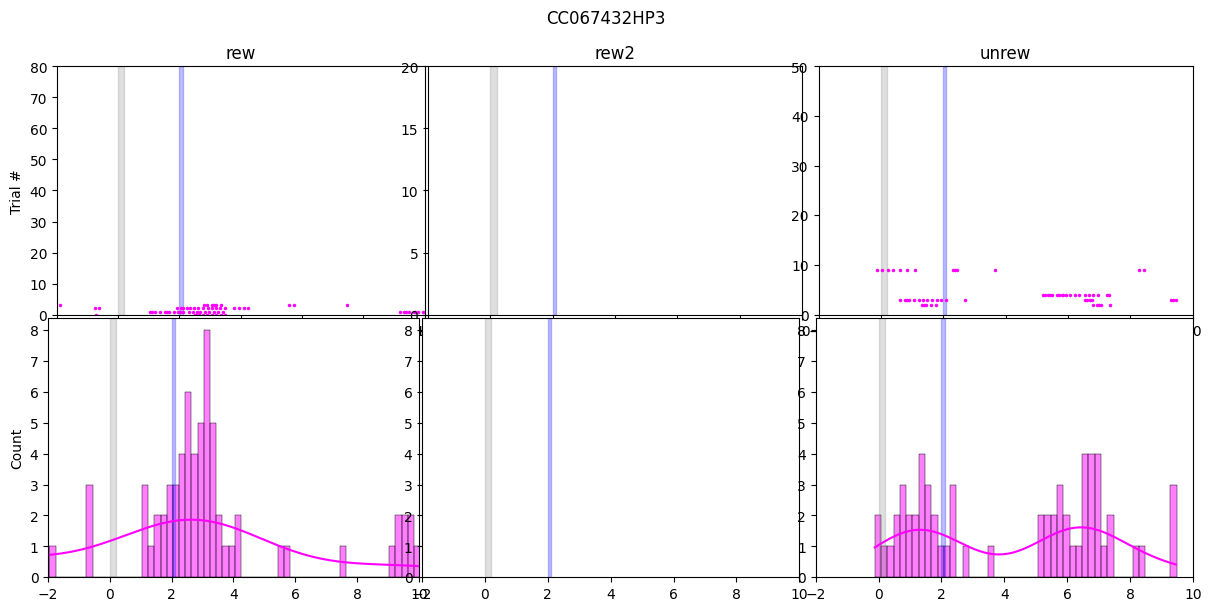

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


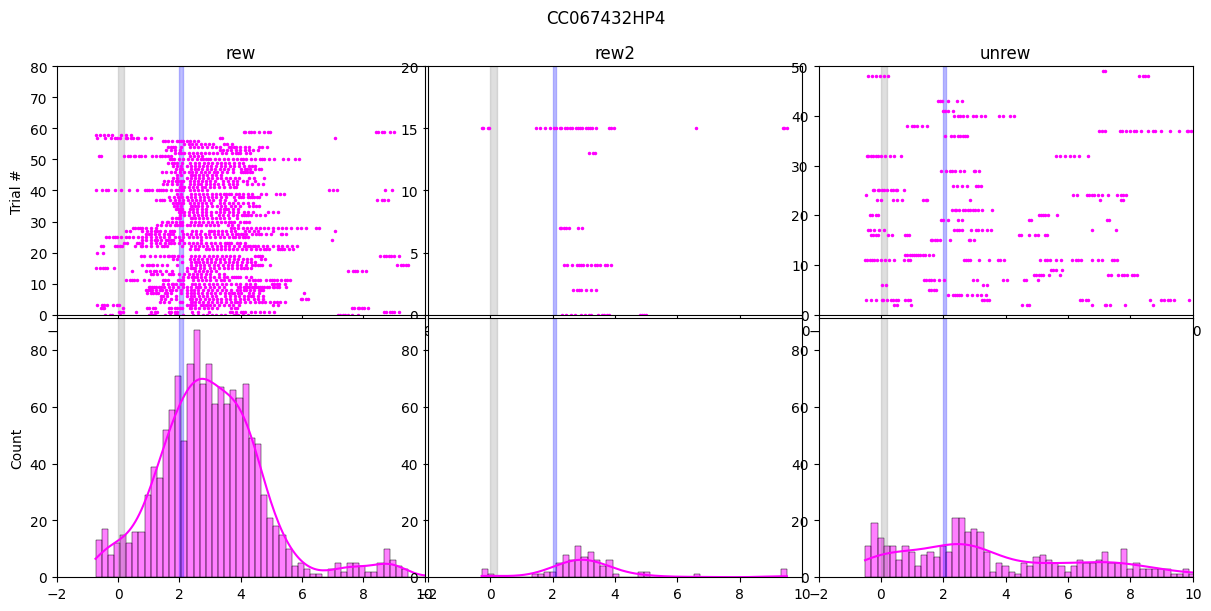

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


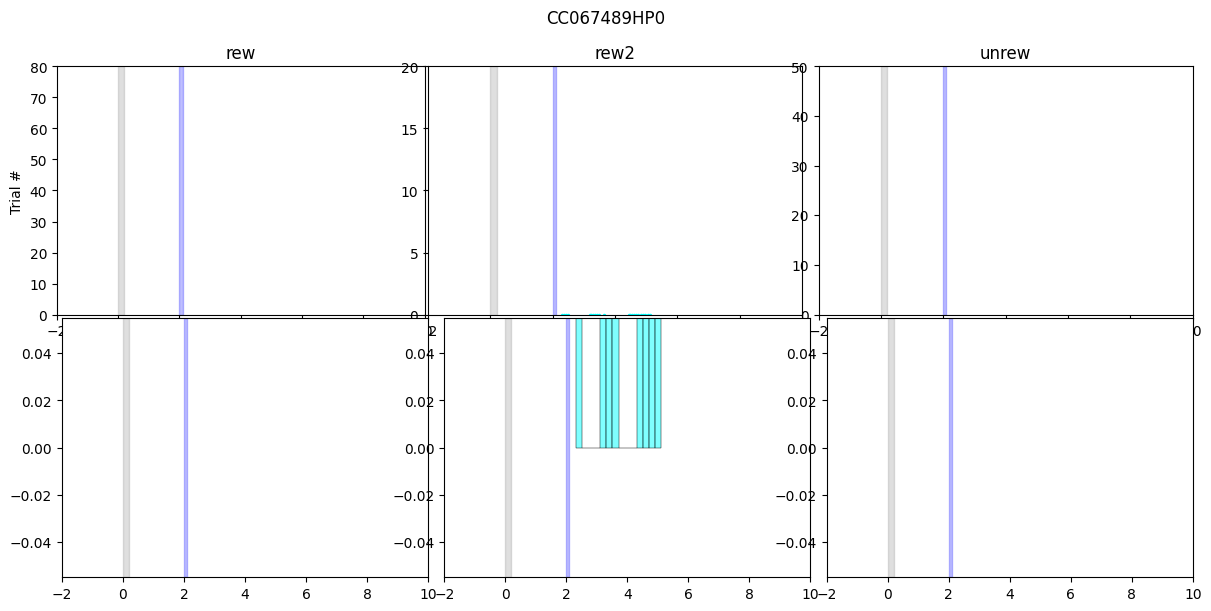

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


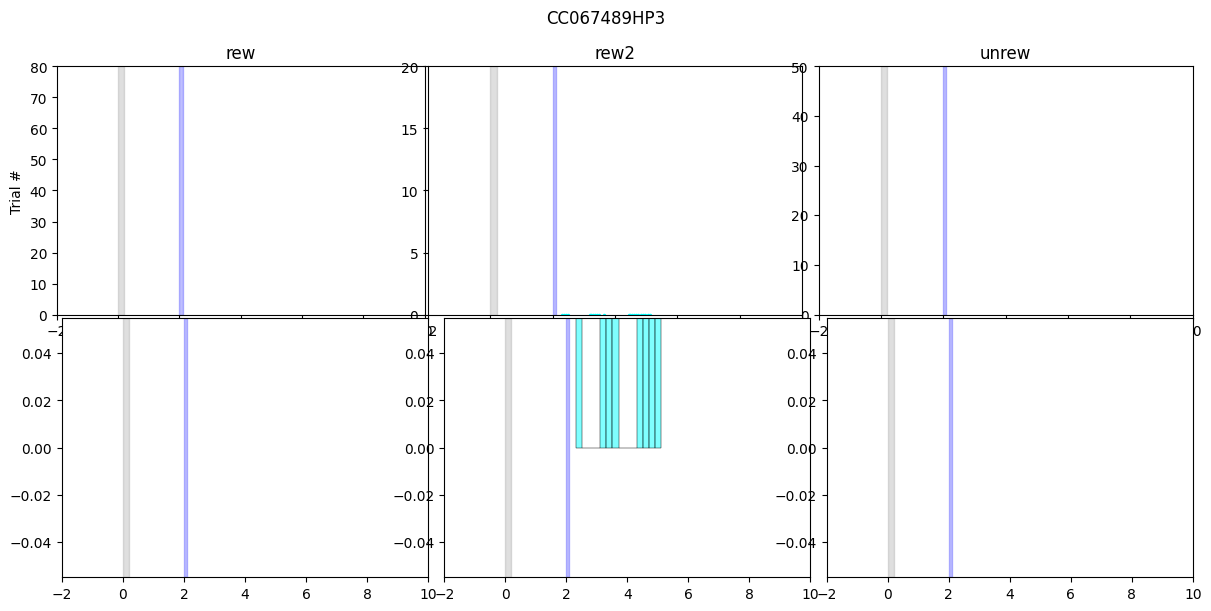

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


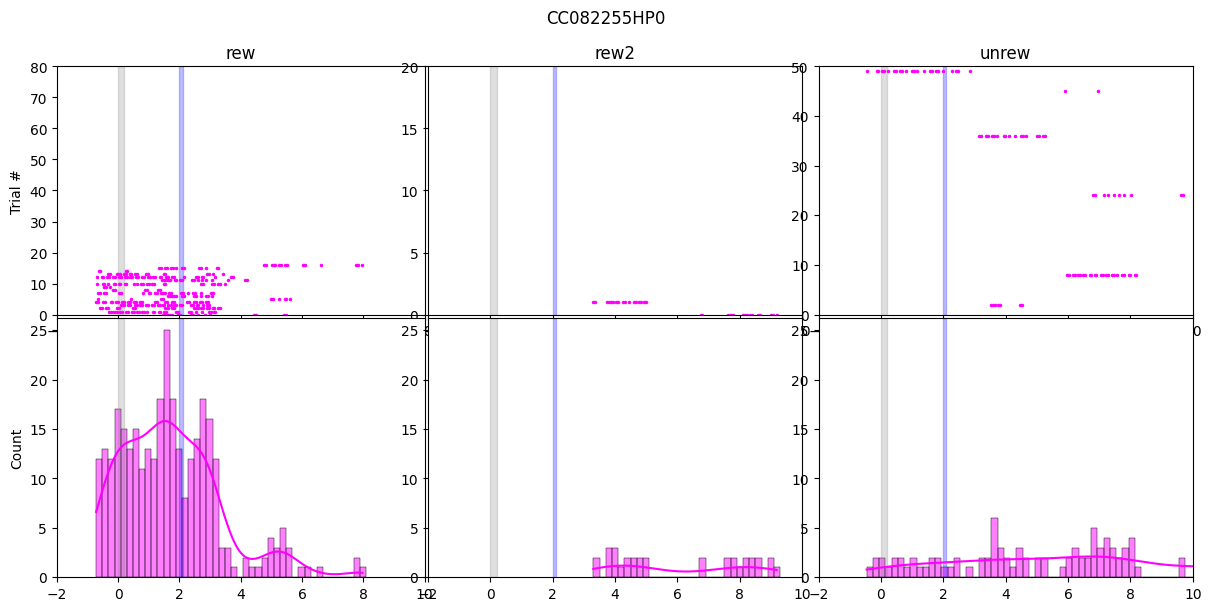

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


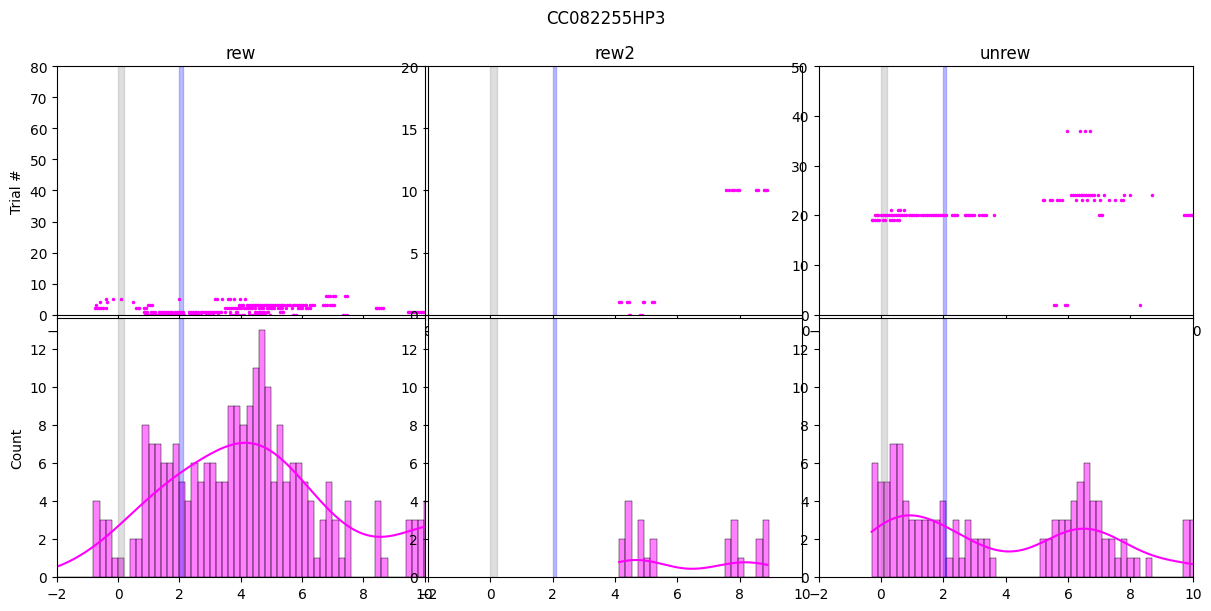

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


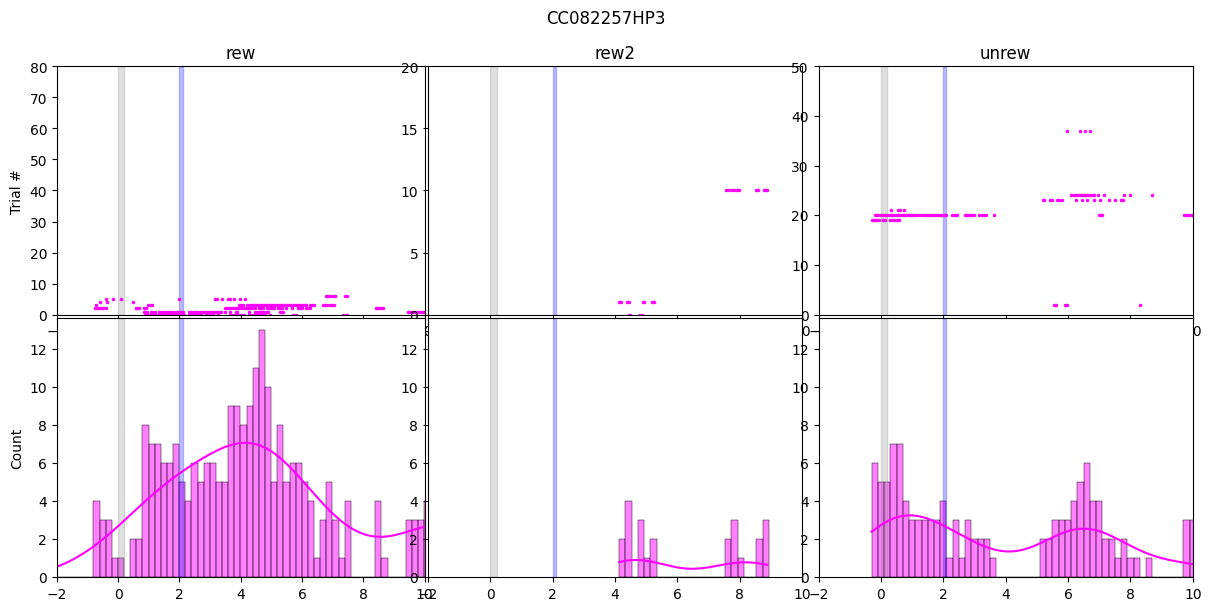

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


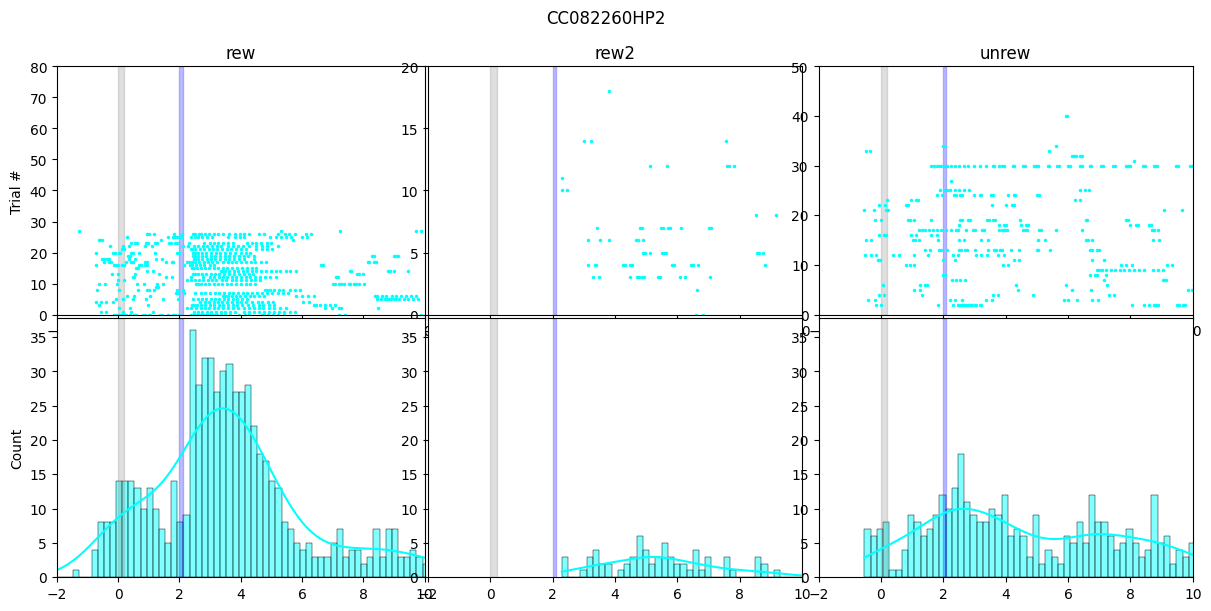

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


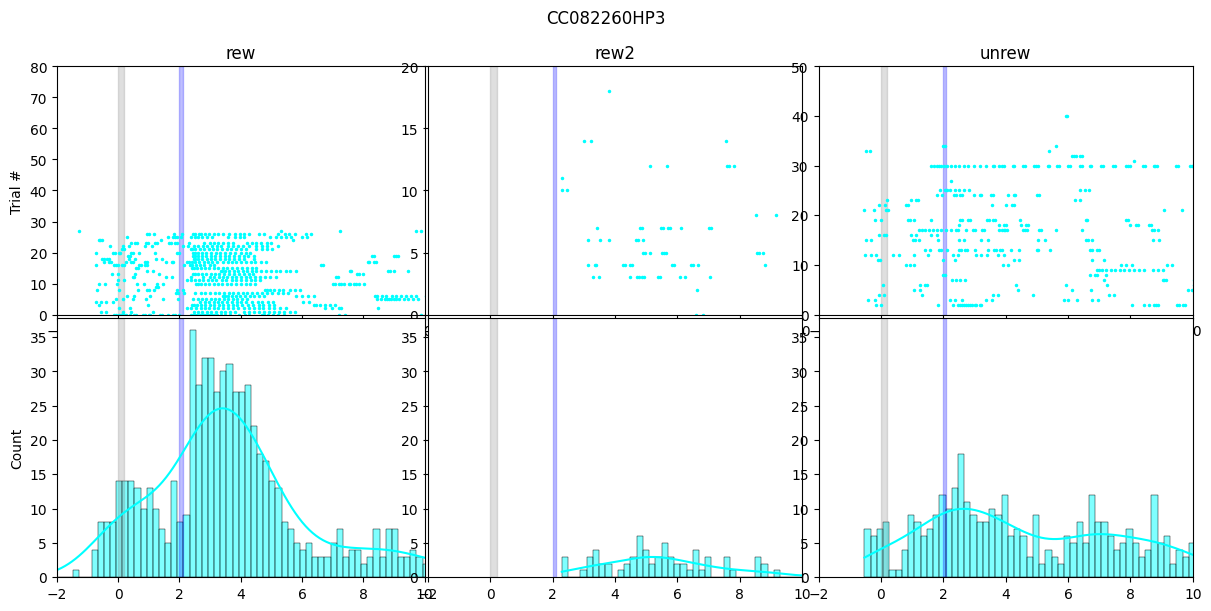

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


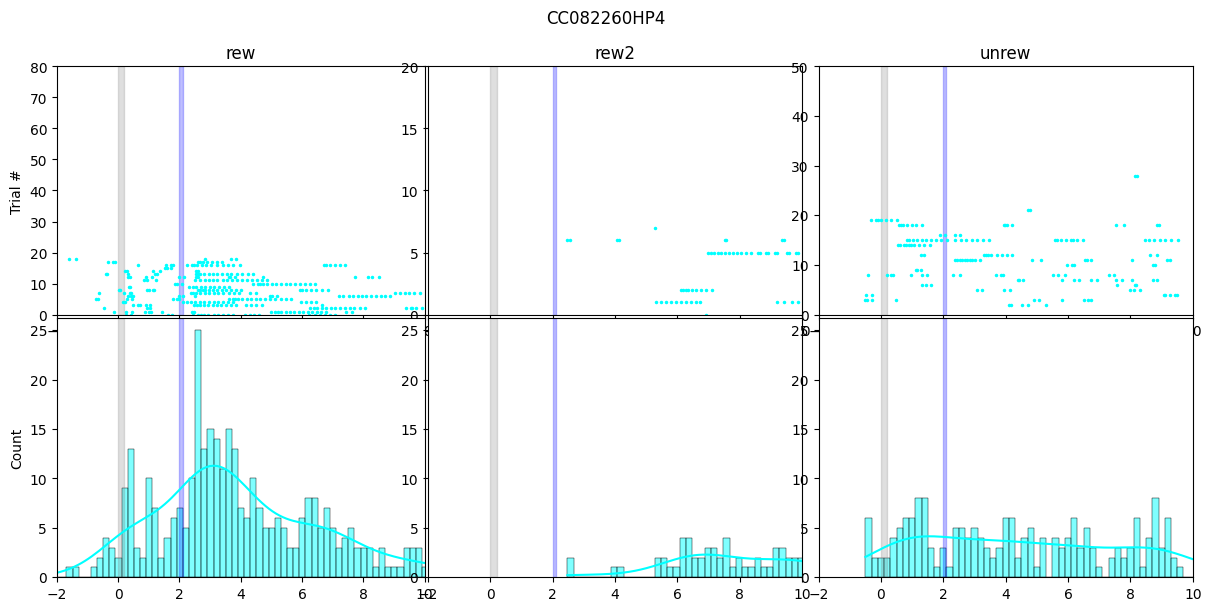

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


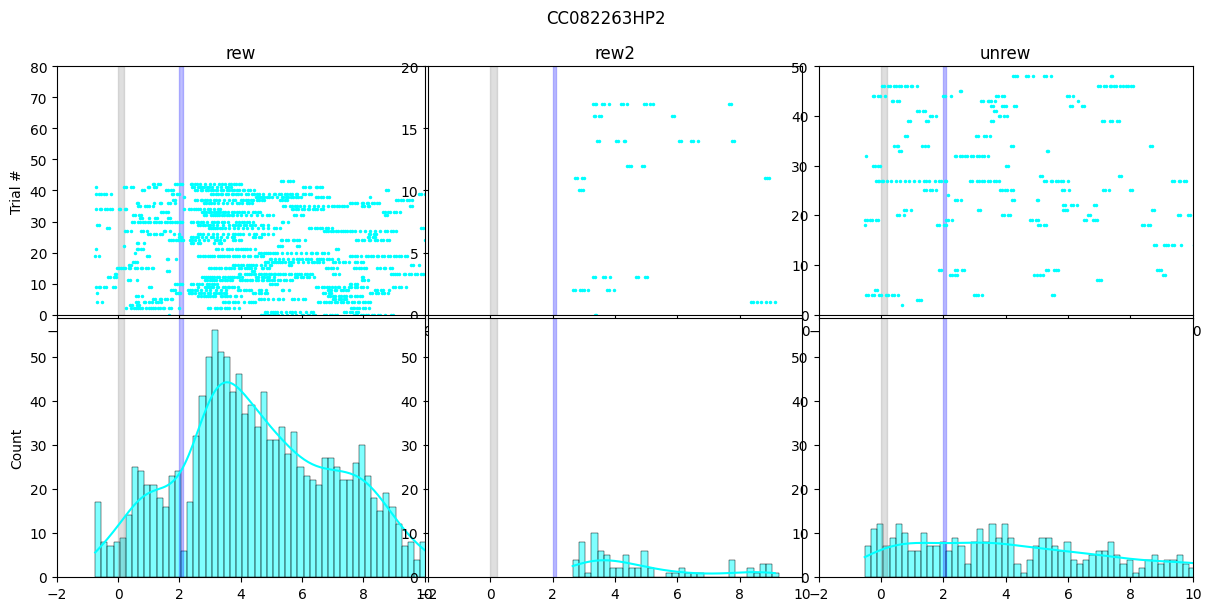

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


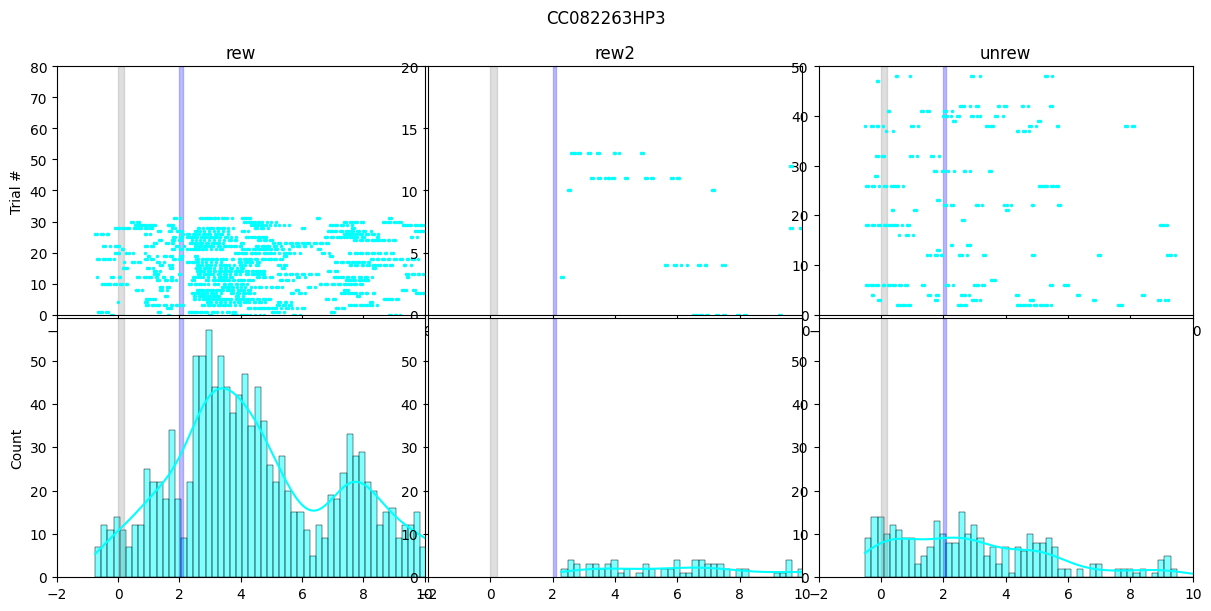

In [79]:
ls = []
for fn in matches[:]:
    f=open(fn, 'rb')
    objs = []
    while 1:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break
    f.close()
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    cc = fn.split('\\')[-1].split('_')[0]
    hp = fn.split('\\')[-1].split('_')[1]
    combo = cc+hp
    if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
        mouse_type = 'WT'
        plt_color = 'cyan'
    elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
        mouse_type = 'FX'
        plt_color = 'magenta'
    else:
        raise ValueError('Incorrect path, check the code...')
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
    df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                    rew_time_ls, 
                                                                                    rew2_time_ls, 
                                                                                    unrew_time_ls, 
                                                                                    miss_ls,
                                                                                    inter_dur)
    df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    rew_df = df_licks2[df_licks2['stim_id'] == 'rew']
    rew2_df = df_licks2[df_licks2['stim_id'] == 'rew2']
    miss_df = df_licks2[df_licks2['stim_id'] == 'miss']
    unrew_df = df_licks2[df_licks2['stim_id'] == 'unrew']
    
    rew_df.loc[:, 'trial'] = rew_df['trial'].apply(lambda x:x-rew_df.trial.min())
    rew2_df.loc[:, 'trial'] = rew2_df['trial'].apply(lambda x:x-rew2_df.trial.min())
    miss_df.loc[:, 'trial'] = miss_df['trial'].apply(lambda x:x-miss_df.trial.min())
    unrew_df.loc[:, 'trial'] = unrew_df['trial'].apply(lambda x:x-99) #x:x-unrew_df.trial.min()
    
    x1 = rew_df.lick_time.values
    y1 = rew_df.trial
    pt1 = 'rew'
    
    x2 = rew2_df.lick_time.values
    y2 = rew2_df.trial
    pt2 = 'rew2'
    
    x3 = miss_df.lick_time.values
    y3 = miss_df.trial
    pt3 = 'iss'
    
    x4 = unrew_df.lick_time.values
    y4 = unrew_df.trial
    pt4 = 'unrew'
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    fig_size = plt.rcParams["figure.figsize"]
    fig_size[0] = 12.0 # x dimension
    fig_size[1] = 6.0 # y dimension
#     plt.rcParams['figure.autolayout'] = True
    plt.rcParams['figure.constrained_layout.use'] = True
#     plt.rcParams.keys() # shows the multiple options for the above layout setting
    
    ax1 = plt.subplot(231)
    plt.plot( x1, y1, '.', markersize=3, color=plt_color)
    stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
    reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward")
    plt.title(pt1)
    plt.ylabel('Trial #')
    ax1.set_xlim(-2,10)
    ax1.set_ylim(0,80)
    
    ax2 = plt.subplot(232, sharex=ax1)
    plt.plot( x2, y2, '.', markersize=3, color=plt_color)
    stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
    reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward")
    plt.title(pt2)
    ax2.set_ylim(0,20)
    ax2.set_yticks([0,5,10,15,20])
    
    ax3 = plt.subplot(233, sharex=ax1)
    plt.plot( x4, y4, '.', markersize=3, color=plt_color)
    stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
    reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward")
    plt.title(pt4)
    ax3.set_ylim(0,50)
    
    
    ax4 = plt.subplot(234, sharex=ax1)
    sns.histplot(x1, binwidth = 0.2, color = plt_color, stat = 'count',kde = True)
    stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
    reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward")
    
    ax5 = plt.subplot(235, sharex=ax1, sharey=ax4)
    sns.histplot(x2, binwidth = 0.2, color = plt_color, stat = 'count',kde = True)
    stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
    reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward")
    ax5.set_ylabel("")
    
    ax6 = plt.subplot(236, sharex=ax1, sharey=ax4)
    sns.histplot(x4, binwidth = 0.2, color = plt_color, stat = 'count',kde = True)
    stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
    reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward")
    ax6.set_ylabel("")
    
    plt.suptitle(combo)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    if save_big_plot == 1:
        save_folder = path + '\\pics' #from where the data was loaded in from
        overall_path = save_folder + "\\RastHist_" + combo + r".pdf"
        plt.savefig(overall_path)
    
    plt.show()

---

---


---


# Averaged lick density per group (wt/fx)

In [136]:
def combo_licks(big_df, group):
    if group == 'WT':
        group_df = big_df[big_df['group'] == 'WT']
    elif group == 'FX':
        group_df = big_df[big_df['group'] == 'FX']
        
    rew_df = group_df[group_df['stim_id'] == 'rew']
    rew2_df = group_df[group_df['stim_id'] == 'rew2']
    unrew_df = group_df[group_df['stim_id'] == 'unrew']
    
#     rew_df.loc[:, 'trial'] = rew_df['trial'].apply(lambda x:x-rew_df.trial.min())
#     rew2_df.loc[:, 'trial'] = rew2_df['trial'].apply(lambda x:x-rew2_df.trial.min())
#     unrew_df.loc[:, 'trial'] = unrew_df['trial'].apply(lambda x:x-99) #x:x-unrew_df.trial.min()
    
    return rew_df, rew2_df, unrew_df

In [134]:
all_mice_df = []
for fn in matches[:]:
    f=open(fn, 'rb')
    objs = []
    while 1:
        try:
            objs.append(pickle.load(f))
        except EOFError:
            break
    f.close()
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    cc = fn.split('\\')[-1].split('_')[0]
    hp = fn.split('\\')[-1].split('_')[1]
    combo = cc+hp
    if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
        mouse_type = 'WT'
        plt_color = 'cyan'
    elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
        mouse_type = 'FX'
        plt_color = 'magenta'
    else:
        raise ValueError('Incorrect path, check the code...')
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
    df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                    rew_time_ls, 
                                                                                    rew2_time_ls, 
                                                                                    unrew_time_ls, 
                                                                                    miss_ls, 
                                                                                    inter_dur)
    df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    df_licks2['et'] = combo
    df_licks2['group'] = mouse_type
    
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    
    all_mice_df.append(df_licks2) #first, append each mouse to a list
    
all_mice_df = pd.concat(all_mice_df,) #second, transform the list to a dataFrame

In [137]:
wt_rew, wt_rew2, wt_unrew = combo_licks(all_mice_df, group='WT')
fx_rew, fx_rew2, fx_unrew = combo_licks(all_mice_df, group='FX')

In [138]:
wt1 = wt_rew.lick_time.values
wt2 = wt_rew2.lick_time.values
wt3 = wt_unrew.lick_time.values

fx1 = fx_rew.lick_time.values
fx2 = fx_rew2.lick_time.values
fx3 = fx_unrew.lick_time.values

pt1 = 'rew'
pt2 = 'rew2'
pt3 = 'unrew'

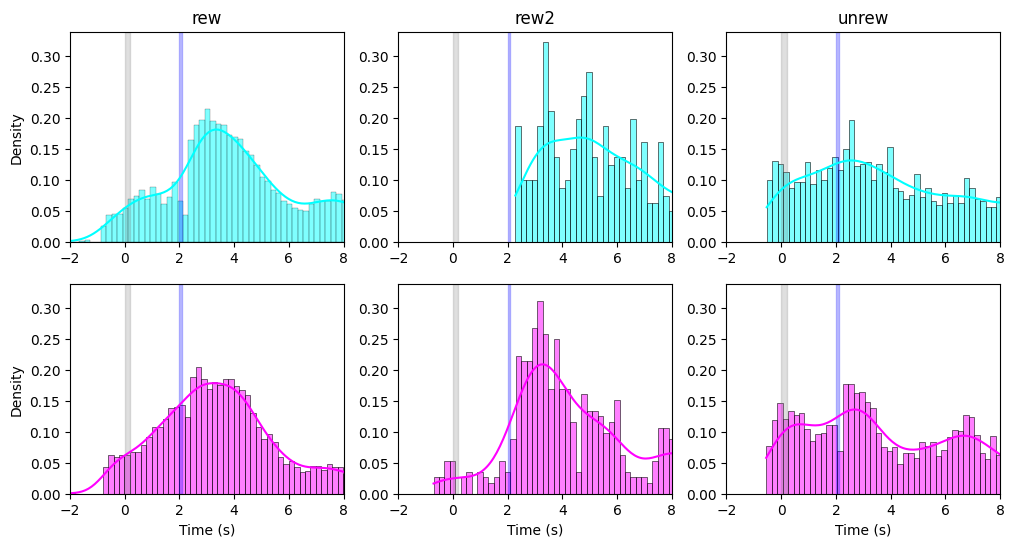

In [141]:
# plt.rcdefaults()

stat_option = 'density'
# plt.suptitle('All mice - Averaged licks')

fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 6.0 # y dimension

plt.tight_layout()
# plt.rcParams['figure.autolayout'] = True
# plt.rcParams['figure.constrained_layout.use'] = True
# plt.rcParams.keys() # shows the multiple options for the above layout setting

ax1 = plt.subplot(231)
sns.histplot(wt1, binwidth = 0.2, color = 'cyan', stat = stat_option, kde = True)
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)

ax2 = plt.subplot(232, sharex=ax1, sharey=ax1)
sns.histplot(wt2, binwidth = 0.2, color = 'cyan', stat = stat_option, kde = True)
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)

ax3 = plt.subplot(233, sharex=ax1, sharey=ax1)
sns.histplot(wt3, binwidth = 0.2, color = 'cyan', stat = stat_option, kde = True)
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)

ax4 = plt.subplot(234, sharex=ax1, sharey=ax1)
sns.histplot(fx1, binwidth = 0.2, color = 'magenta', stat = stat_option, kde = True)
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax5 = plt.subplot(235, sharex=ax1, sharey=ax1)
sns.histplot(fx2, binwidth = 0.2, color = 'magenta', stat = stat_option, kde = True)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax6 = plt.subplot(236, sharex=ax1, sharey=ax1)
sns.histplot(fx3, binwidth = 0.2, color = 'magenta', stat = stat_option, kde = True)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\2sec_density.pdf", transparent=True)

plt.show()

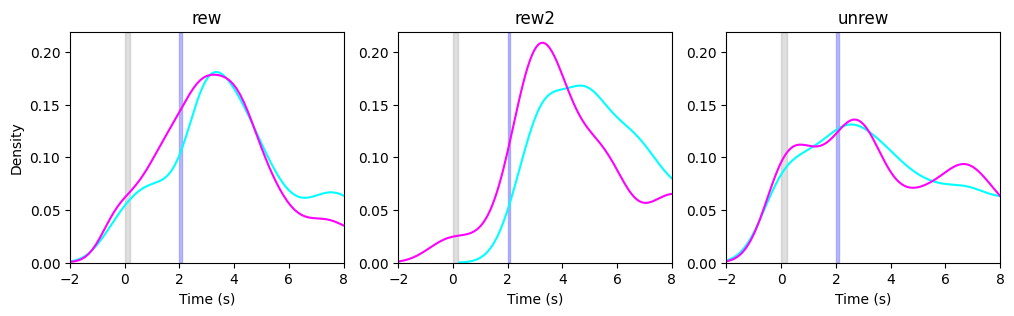

In [143]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

ax1 = plt.subplot(131)
sns.kdeplot(wt1, color='cyan')
sns.kdeplot(fx1, color='magenta')
plt.title(pt1)
plt.xlim([-2,8])
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax2 = plt.subplot(132, sharex=ax1, sharey=ax1)
sns.kdeplot(wt2, color='cyan')
sns.kdeplot(fx2, color='magenta')
plt.title(pt2)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1, sharey=ax1)
sns.kdeplot(wt3, color='cyan')
sns.kdeplot(fx3, color='magenta')
plt.title(pt3)
plt.ylabel('')
plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25)
plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\averaged\2sec_kde.pdf", transparent=True)

plt.show()